In [4]:
# NAIVE BAYES AND NLP

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import string

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix)

In [7]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\aquib\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\aquib\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\aquib\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [8]:
df = pd.read_csv("blogs.csv")
df.head()

,Data,Labels
0,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism
1,Newsgroups: alt.atheism\nPath: cantaloupe.srv....,alt.atheism
2,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,alt.atheism
3,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism
4,Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...,alt.atheism


In [9]:
#-> EDA

In [10]:
df.shape

(2000, 2)

In [11]:
df.columns

Index(['Data', 'Labels'], dtype='str')

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Data    2000 non-null   str  
 1   Labels  2000 non-null   str  
dtypes: str(2)
memory usage: 4.5 MB


In [13]:
df.isnull().sum()

Data      0
Labels    0
dtype: int64

In [14]:
df['Labels'].value_counts()

Labels
alt.atheism                 100
comp.graphics               100
comp.os.ms-windows.misc     100
comp.sys.ibm.pc.hardware    100
comp.sys.mac.hardware       100
comp.windows.x              100
misc.forsale                100
rec.autos                   100
rec.motorcycles             100
rec.sport.baseball          100
rec.sport.hockey            100
sci.crypt                   100
sci.electronics             100
sci.med                     100
sci.space                   100
soc.religion.christian      100
talk.politics.guns          100
talk.politics.mideast       100
talk.politics.misc          100
talk.religion.misc          100
Name: count, dtype: int64

In [15]:
##-> There are no missing values in both columns, and all the values are in strings.

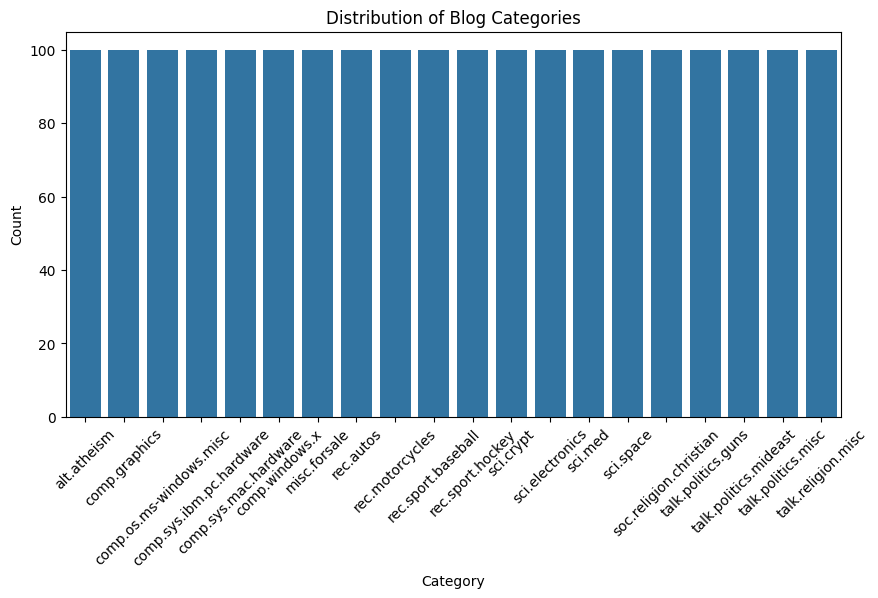

In [16]:
plt.figure(figsize=(10,5))
sns.countplot(x='Labels',data=df,order=df['Labels'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Distribution of Blog Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

In [17]:
##-> The dataset was successfully loaded and explored. It contains blog posts along with their corresponding categories. Initial exploration included checking the dataset dimensions, column names, missing values, and the distribution of blog categories.

In [18]:
stop_words = set(stopwords.words('english'))

In [19]:
def preprocess_text(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)

In [20]:
df['Cleaned_Data'] = df['Data'].apply(preprocess_text)

In [22]:
import re

In [23]:
def preprocess_text(text):
    text = str(text)
    text = re.sub(r'^Path:.*?(?=\n\n)', '', text, flags=re.DOTALL | re.IGNORECASE)
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = word_tokenize(text)
    tokens = [
    word for word in tokens if word not in stop_words and word.isalpha()]
    return " ".join(tokens)

In [24]:
df['Cleaned_Data'] = df['Data'].apply(preprocess_text)

In [25]:
print(df.loc[0, 'Cleaned_Data'])

article jon livesey writes article frank odwyer writes article jon livesey writes noting particular society case mainland uk religously motivated murders murders kind says little whether interreligion murders elsewhere religiously motivated allows one conclude nothing inherent religion matter catholicism protestantism motivates one kill motivates allows christian bible says one may kill certain circumstances fact instructs one kill certain circumstances id say majority people moral system instructs kill certain circumstances get distinction motivate allow agree flavour theism allows atoricities thats indictment theism rather depends certain circumstances talk christianity islam least claims understood people go general statement theism falls apart one could believe god instructs one utterly harmless part conclude something else required also happen believe something else work less well without religion easy themus religion supply easy themus necessarily love thy neighbour supply themus

In [27]:
tfidf = TfidfVectorizer(max_df=0.95,min_df=2)
X = tfidf.fit_transform(df['Cleaned_Data'])
y = df['Labels']

In [28]:
X.shape

(2000, 15082)

In [30]:
tfidf.get_feature_names_out()[:20]

array(['aa', 'aaa', 'aarhus', 'aaron', 'ab', 'abandon', 'abandoned',
       'abate', 'abbreviation', 'abc', 'abdullah', 'abel', 'abhorrant',
       'abilities', 'ability', 'abiogenesis', 'able', 'abnormalities',
       'abolish', 'abolished'], dtype=object)

In [39]:
##-> The cleaned textual data was transformed into numerical feature vectors using the TF-IDF technique. This method assigns weights to words based on their frequency within a document and their rarity across the entire corpus, making it suitable for text classification tasks.

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [41]:
print("Training Data Shape :", X_train.shape)
print("Testing Data Shape  :", X_test.shape)

Training Data Shape : (1600, 15082)
Testing Data Shape  : (400, 15082)


In [46]:
nb_model = MultinomialNB()

In [47]:
nb_model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [48]:
y_pred = nb_model.predict(X_test)

In [49]:
print(y_pred[:10])

['talk.politics.misc' 'comp.sys.ibm.pc.hardware' 'sci.med'
 'rec.sport.baseball' 'sci.electronics' 'sci.electronics'
 'rec.sport.baseball' 'talk.politics.mideast' 'alt.atheism' 'sci.med']


In [50]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy :", accuracy)

Accuracy : 0.74


In [51]:
print(classification_report(y_test, y_pred))

                          precision    recall  f1-score   support

             alt.atheism       0.38      0.61      0.47        18
           comp.graphics       0.72      0.72      0.72        18
 comp.os.ms-windows.misc       0.68      0.77      0.72        22
comp.sys.ibm.pc.hardware       0.70      0.64      0.67        25
   comp.sys.mac.hardware       0.69      0.52      0.59        21
          comp.windows.x       0.90      0.72      0.80        25
            misc.forsale       0.92      0.61      0.73        18
               rec.autos       0.88      0.83      0.86        18
         rec.motorcycles       0.88      0.88      0.88        16
      rec.sport.baseball       0.81      0.94      0.87        18
        rec.sport.hockey       0.83      1.00      0.91        15
               sci.crypt       0.69      0.95      0.80        19
         sci.electronics       0.46      0.75      0.57        16
                 sci.med       0.83      0.88      0.86        17
         

In [56]:
cm = confusion_matrix(y_test, y_pred)

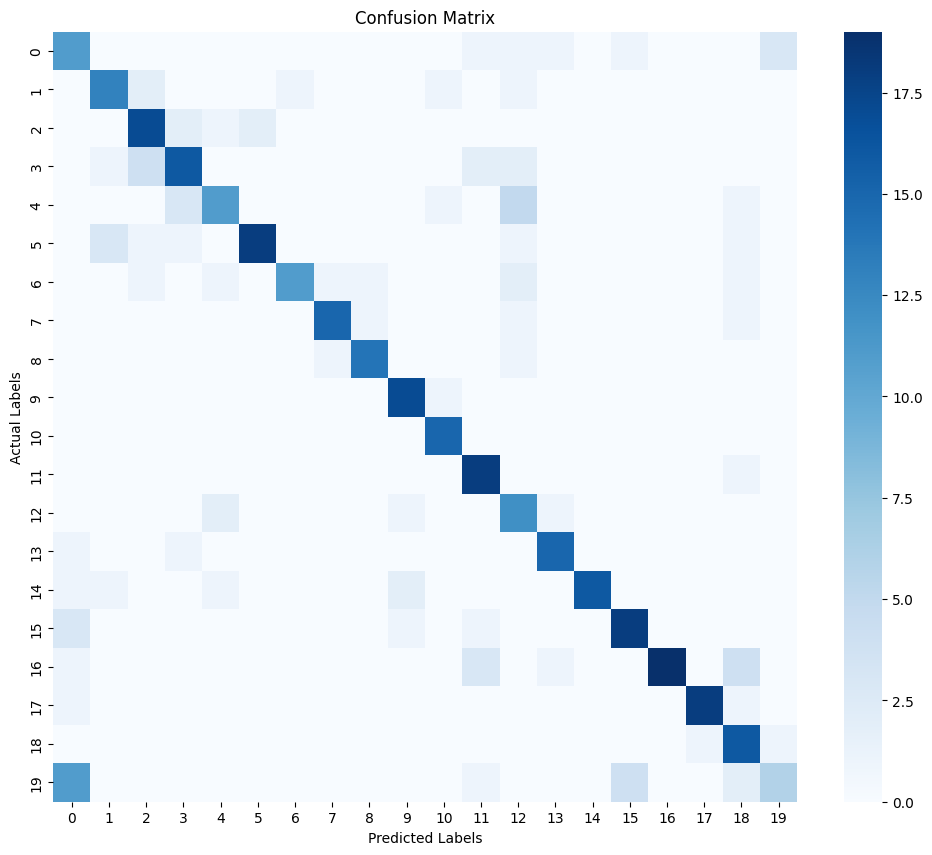

In [57]:
plt.figure(figsize=(12,10))
sns.heatmap(cm,cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")
plt.show()

In [58]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\aquib\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [59]:
from nltk.sentiment import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

In [108]:
def sentiment_clean(text):

    text = str(text)

    lines = text.split('\n')

    cleaned_lines = []

    headers = [
    'Path:',
    'From:',
    'Newsgroups:',
    'Subject:',
    'Date:',
    'Organization:',
    'Lines:',
    'Distribution:',
    'Message-ID:',
    'References:',
    'NNTP-Posting-Host:',
    'Xref:',
    'Sender:',
    'Reply-To:',
    'Keywords:',
    'Summary:',
    'Expires:',
    'Followup-To:'
    ]

    for line in lines:

        if any(line.startswith(header) for header in headers):
            continue

        cleaned_lines.append(line)

    return " ".join(cleaned_lines)

In [110]:
df['Sentiment_Text'] = df['Data'].apply(sentiment_clean)

In [112]:
print(df.loc[0, 'Sentiment_Text'])

 In article <1r76ek$7uo@fido.asd.sgi.com> livesey@solntze.wpd.sgi.com (Jon Livesey) writes: #In article <1r5ubl$bd6@horus.ap.mchp.sni.de>, frank@D012S658.uucp (Frank O'Dwyer) writes: #|> In article <1r4o8a$6qe@fido.asd.sgi.com> livesey@solntze.wpd.sgi.com (Jon Livesey) writes: #|> # #|> #Noting that a particular society, in this case the mainland UK, #|> #has few religously motivated murders, and few murders of *any* #|> #kind, says very little about whether inter-religion murders elsewhere #|> #are religiously motivated. #|>  #|> No, but it allows one to conclude that there is nothing inherent #|> in all religion (or for that matter, in catholicism and protestantism) #|> that motivates one to kill. # #"Motivates" or "allows?"    The Christian Bible says that one may kill #under certain circumstances.   In fact, it instructs one to kill under #certain circumstances.       I'd say the majority of people have a moral system that instructs them to kill under certain circumstances.  I do g

In [114]:
def get_sentiment(text):
    score = sia.polarity_scores(text)['compound']

    if score >= 0.05:
        return 'Positive'

    elif score <= -0.05:
        return 'Negative'

    else:
        return 'Neutral'

In [116]:
df['Sentiment'] = df['Sentiment_Text'].apply(get_sentiment)

In [117]:
df[['Sentiment_Text', 'Sentiment']].head()

,Sentiment_Text,Sentiment
0,In article <1r76ek$7uo@fido.asd.sgi.com> live...,Negative
1,Nntp-Posting-Host: okcforum.osrhe.edu X-Newsre...,Positive
2,In article <1993Apr16.222525.16024@bnr.ca> (R...,Negative
3,In article <930420.105805.0x8.rusnews.w165w@m...,Negative
4,"In article <30151@ursa.bear.com>, halat@pooh....",Positive


In [120]:
df['Sentiment'].value_counts()

Sentiment
Positive    1325
Negative     615
Neutral       60
Name: count, dtype: int64

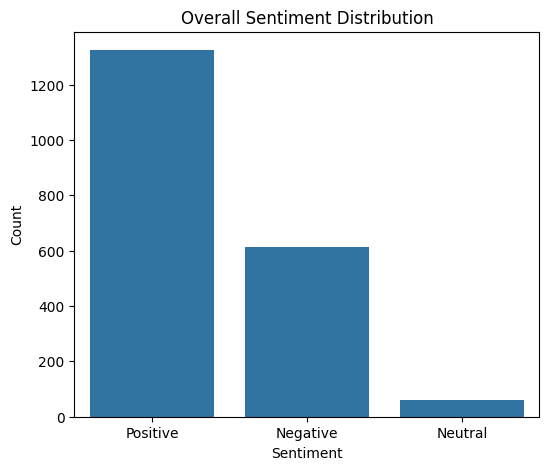

In [122]:
plt.figure(figsize=(6,5))
sns.countplot(x='Sentiment',data=df,order=df['Sentiment'].value_counts().index)

plt.title("Overall Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [124]:
##-> Sentiment analysis was performed on the blog posts using the VADER sentiment analyzer. 
##-> The results indicate that the majority of posts were classified as Positive, followed by Negative and Neutral sentiments. 
##-> This suggests that most blog discussions contain opinionated or emotionally expressive language rather than purely factual content. 
##-> The sentiment labels generated were further used to analyze sentiment distribution across different blog categories and understand the overall tone of the dataset.